In [5]:
import math
import tqdm
import torch
import gpytorch
from matplotlib import pyplot as plt
import scipy.io as sio
import numpy as np
import os
import torch.nn as nn
import numpy.linalg as LA
import ipdb
from torch.utils.data import TensorDataset, DataLoader
import datetime
#import iri2016 as iri
#import iri2016.plots
from pyiri2016 import IRI2016
# Make plots inline
%matplotlib inline

smoke_test = ('CI' in os.environ)


1.0
365.0
1.0
31.0
(3300000, 6)


<IPython.core.display.Javascript object>


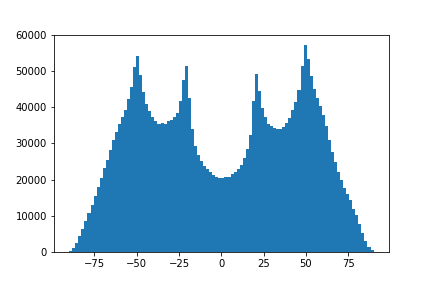

660023
tensor(65.7218)
tensor(0.0406)
tensor([ -42.6049, -163.7407,    2.7500,   -2.5800,  -18.5000,  311.0000,
         -16.0000,  182.0000])
torch.Size([2958111, 8])
torch.Size([2958111, 1])
tensor(0.0020)
torch.Size([2373173, 8])
torch.Size([2373173, 1])
torch.Size([489919, 8])
torch.Size([95019, 8])


In [6]:
%matplotlib notebook

############################ load the data ############
i = 0
#data = sio.loadmat('data/Delay/all_'+str(i)+'.mat')
data_RO = sio.loadmat('data/Delay/330w_0_minutes_geog.mat')

ALT = data_RO['out'][:,0]
mLat = data_RO['out'][:,1]
#ipdb.set_trace()

mLon = data_RO['out'][:,2]
mLT = data_RO['out'][:,3]
VTEC0 = data_RO['out'][:,4]

varis = data_RO['out'][:,5:9]
DoY = np.array(data_RO['out'][:,9])
VTEC1 = data_RO['out'][:,10]
NmF2 = data_RO['out'][:,11]
year = data_RO['out'][:,12]

Month = np.zeros(len(DoY))
DoM = np.zeros(len(DoY))

print(DoY.min())
print(DoY.max())

for i in range(len(DoY)):
    date = datetime.datetime(int(year[i]), 1, 1) + datetime.timedelta(int(DoY[i]) - 1)

    Month[i] = date.month
    DoM[i] = date.day
    

print(DoM.min())
print(DoM.max())

LT = mLT + mLon/15

for i in range(len(LT)):
    if LT[i] >= 24:
        LT[i] -= 24
    elif LT[i] < 0:
        LT[i] += 24

Ref_iri = np.vstack([year,Month,DoM,LT,mLat,mLon]).T
print(Ref_iri.shape)

Vari_idx = [1,2,3,5,6,7,8,9]
Target = [11]

ind = np.where((np.abs(mLat)>0) \
                   & (~np.isnan(varis[:,0])) \
                   #& (varis[:,0]>-30) \
                   & (~np.isnan(varis[:,1])) \
                   & (~np.isnan(varis[:,2])) \
                   & (~np.isnan(varis[:,3])) \
                   #& (varis[:,3]<120) \
                   & (ALT>200) \
                   & (ALT<400) \
                   & (NmF2>np.exp(9.5)) \
                   & (NmF2<np.exp(15))
                   & (VTEC0 < 60)
                   & (VTEC0 > 0)
                  )[0]

def seed_torch(seed):
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_torch(1029)

data = torch.from_numpy(data_RO['out'][ind,:]).type( torch.FloatTensor )
Ref_iri = Ref_iri[ind,:]
#X[:,2] = torch.from_numpy(LT[ind])

#Y = torch.from_numpy(np.sqrt(data['out'][ind,16]/(1.24e4))).type( torch.FloatTensor )

#ipdb.set_trace()

plt.hist(data[:,1],100)
plt.show()

#data[:,1] = np.cos(data[:,1]*np.pi/180)
#data[:,1] = np.sin(data[:,1]*np.pi/180)
#data[:,3] = np.sin(data[:,3]*np.pi/24)
#data[:,9] = np.sin(data[:,9]*np.pi/365)

ind_vtec = np.where((VTEC1[ind]>0) \
                     & (VTEC1[ind]<VTEC0[ind]/20))[0]
print(len(ind_vtec))
data[ind_vtec,4] = data[ind_vtec,4]+data[ind_vtec,10]
data[~ind_vtec,4] = data[~ind_vtec,4]*1.05

print(data[:,4].max())
print(data[:,4].min())

X = data[:,Vari_idx]
Y = data[:,Target]
Ref = data


X_save = X
Y_save = Y

#Y = (Y - Y_save.min())/(Y_save.max()-Y_save.min())

#ipdb.set_trace()
Ref = data[:,12]


### Normlisation
#X = X/LA.norm(X)
#Y = Y/LA.norm(Y)

print(X[1,:])

print(X.shape)
print(Y.shape)

idx_train = np.where((Ref!=2009) & (Ref!=2014))[0]
idx_test = np.where((Ref==2009) | (Ref==2014))[0]
idx_test1 = np.where((Ref==2009))[0]
idx_test2 = np.where((Ref==2014))[0]

#idx_test_t = idx_test2
#train_n = int(0.8 * len(X))
train_x = X[idx_train, :].contiguous()
train_y = Y[idx_train].contiguous()

test_x1 = X[idx_test1, :].contiguous()
test_y1 = Y[idx_test1].contiguous()
test_x2 = X[idx_test2, :].contiguous()
test_y2 = Y[idx_test2].contiguous()

print(np.abs(test_x1[:,0]).min())

'''
batch_size = 256
train_x = train_x[0:int(len(idx_train)/batch_size)*batch_size,:].view(
                [batch_size, int(len(idx_train)/batch_size),\
                len(Vari_idx)])
train_y = train_y[0:int(len(idx_train)/batch_size)*batch_size].view(
                [batch_size,int(len(idx_train)/batch_size)])

test_x = test_x[0:int(len(idx_test_t)/batch_size)*batch_size,:].view(
                [batch_size, int(len(idx_test_t)/batch_size),\
                len(Vari_idx)])
test_y = test_y[0:int(len(idx_test_t)/batch_size)*batch_size].view(
                [batch_size,int(len(idx_test_t)/batch_size)])

if torch.cuda.is_available():
    test_x1, test_y1, test_x2, test_y2 =\
    test_x1.cuda(), test_y1.cuda(),\
    test_x2.cuda(), test_y2.cuda(),
'''
print(train_x.shape)
print(train_y.shape)

print(test_x1.shape)
print(test_x2.shape)
#batch_num = torch.Size([train_x.shape[0]])
#print(batch_num)


In [11]:
################################ RO IRI ################

from pyiri2016 import IRI2016

from multiprocessing import cpu_count, Pool
from random import sample
import tqdm
import torch

cores = cpu_count()
#print(cores)

#data = sio.loadmat('../Omni_data/HRO.mat')

Ref = Ref_iri
Y = np.array(Y).squeeze()

ind_2009_low = np.where((Ref[:,0]==2009) \
                       & (np.abs(Ref[:,4])<=30)
                       & (~np.isnan(Ref[:,2]))
                       & (~np.isnan(Ref[:,3]))
                       & (~np.isnan(Ref[:,5]))
                       )[0]
ind_2009_mid = np.where((Ref[:,0]==2009) \
                       & (np.abs(Ref[:,4])>=30)
                       & (np.abs(Ref[:,4])<60)
                        & (~np.isnan(Ref[:,1]))
                       & (~np.isnan(Ref[:,2]))
                       & (~np.isnan(Ref[:,3]))
                       & (~np.isnan(Ref[:,5]))
                       )[0]
ind_2009_high = np.where((Ref[:,0]==2009) \
                       & (np.abs(Ref[:,4])>=60)
                        & (~np.isnan(Ref[:,1]))
                       & (~np.isnan(Ref[:,2]))
                       & (~np.isnan(Ref[:,3]))
                       & (~np.isnan(Ref[:,5]))
                       )[0]

ind_2014_low = np.where((Ref[:,0]==2014) \
                       & (np.abs(Ref[:,4])<=30)
                        & (~np.isnan(Ref[:,1]))
                       & (~np.isnan(Ref[:,2]))
                       & (~np.isnan(Ref[:,3]))
                       & (~np.isnan(Ref[:,5]))
                       )[0]
ind_2014_mid = np.where((Ref[:,0]==2014) \
                       & (np.abs(Ref[:,4])>=30)
                       & (np.abs(Ref[:,4])<60)
                        & (~np.isnan(Ref[:,1]))
                       & (~np.isnan(Ref[:,2]))
                       & (~np.isnan(Ref[:,3]))
                       & (~np.isnan(Ref[:,5]))
                       )[0]
ind_2014_high = np.where((Ref[:,0]==2014) \
                       & (np.abs(Ref[:,4])>=60)
                         & (~np.isnan(Ref[:,1]))
                       & (~np.isnan(Ref[:,2]))
                       & (~np.isnan(Ref[:,3]))
                       & (~np.isnan(Ref[:,5]))
                       )[0]


def init():
    global Ref_iri
    global Y

def generate_NmF2(idx):
    Obj = IRI2016()
    try:
        IRIData, IRIDATAAdd = Obj.IRI(dom=int(Ref[idx,2]), glat=float(Ref[idx,4]), glon=float(Ref[idx,5]),
                                      hrlt=float(Ref[idx,3]), month=int(Ref[idx,1]), var=1, vbeg=130.,
                                      vend=130.+1., vstp=1., year=int(Ref[idx,0]))
    except:
        print('something wrong with IRI')
        return -1

    return IRIDATAAdd['NmF2']/1e6

p = Pool(cores,init,())
#num_test = int(Ref.shape[0]/10)

#################### low solar activity and low latitude ############

idx_test = ind_2009_low
NmF2 = []

for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test) \
                   , total=len(idx_test)):
    #pass
    NmF2.append(t)

RO_iri_2009_low = torch.from_numpy(np.array(NmF2))
RO_NmF2_2009_low = torch.from_numpy(Y[idx_test])
RMSE_RO_2009_low = torch.sqrt(
        torch.mean((RO_NmF2_2009_low - RO_iri_2009_low)**2))

print('Test RMSE in RO: {}'.format(RMSE_RO_2009_low))

#################### low solar activity and mid latitude ############
idx_test = ind_2009_mid
NmF2 = []

for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test) \
                   , total=len(idx_test)):
    #pass
    NmF2.append(t)

RO_iri_2009_mid = torch.from_numpy(np.array(NmF2))
RO_NmF2_2009_mid = torch.from_numpy(Y[idx_test])

#################### low solar activity and high latitude ############
idx_test = ind_2009_high
NmF2 = []

for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test) \
                   , total=len(idx_test)):
    #pass
    NmF2.append(t)

RO_iri_2009_high = torch.from_numpy(np.array(NmF2))
RO_NmF2_2009_high = torch.from_numpy(Y[idx_test])

#################### high solar activity and low latitude ############
idx_test = ind_2014_low
NmF2 = []

for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test) \
                   , total=len(idx_test)):
    #pass
    NmF2.append(t)

RO_iri_2014_low = torch.from_numpy(np.array(NmF2))
RO_NmF2_2014_low = torch.from_numpy(Y[idx_test])

#################### high solar activity and mid latitude ############
idx_test = ind_2014_mid
NmF2 = []

for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test) \
                   , total=len(idx_test)):
    #pass
    NmF2.append(t)

RO_iri_2014_mid = torch.from_numpy(np.array(NmF2))
RO_NmF2_2014_mid = torch.from_numpy(Y[idx_test])

#################### high solar activity and high latitude ############
idx_test = ind_2014_high
NmF2 = []

for t in tqdm.tqdm(p.imap_unordered(generate_NmF2, idx_test) \
                   , total=len(idx_test)):
    #pass
    NmF2.append(t)

RO_iri_2014_high = torch.from_numpy(np.array(NmF2))
RO_NmF2_2014_high = torch.from_numpy(Y[idx_test])

RO_iri = [RO_iri_2009_low,
            RO_iri_2009_mid,
            RO_iri_2009_high,
            RO_iri_2014_low,
            RO_iri_2014_mid,
            RO_iri_2014_high
           ]
print(RO_iri[0].shape)
RO_NmF2 = [RO_NmF2_2009_low,
             RO_NmF2_2009_mid,
             RO_NmF2_2009_high,
             RO_NmF2_2014_low,
             RO_NmF2_2014_mid,
             RO_NmF2_2014_high
            ]
print(RO_NmF2[0].shape)

RMSE_RO_iri = torch.zeros(6)
for i in range(6):
    RMSE_RO_iri[i] = torch.sqrt(
        torch.mean((RO_iri[i] - RO_NmF2[i].squeeze())**2))

print('Test RMSE in RO: {}'.format(RMSE_RO_iri))

  0%|          | 25/224132 [00:00<15:37, 239.04it/s]

Test RMSE in RO: 242645.07311375966


100%|██████████| 21760/21760 [01:16<00:00, 284.19it/s]

torch.Size([178473])
torch.Size([178473])
Test RMSE in RO: tensor([242645.0781, 102168.8672,  66066.3438, 406492.9375, 348691.6875,
        279180.1875])
